# Практика 11. Числові характеристики випадкової величини; закон великих чисел і ЦГТ симуляцією

**Варіант 1: Київ**

Мета: симуляцією перевірити, що вибіркове середнє наближається до теоретичного середнього за законом великих чисел, а його розподіл стає близьким до нормального за центральною граничною теоремою.

Для часу очікування використано експоненційний розподіл із параметром `lambda = 0.20` подій/хв. Теоретичне середнє: `E[X] = 1 / lambda = 5` хв.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

variant = 1
city = 'Київ'
lam = 0.20
true_mean = 1 / lam
rng = np.random.default_rng(variant)
n_repeats = 10_000

print(f'Місто: {city}')
print(f'lambda = {lam:.2f} подій/хв')
print(f'Теоретичне E[X] = {true_mean:.2f} хв')

Місто: Київ
lambda = 0.20 подій/хв
Теоретичне E[X] = 5.00 хв


## Завдання 1. Перевірка закону великих чисел

Для кожного розміру вибірки генеруємо час очікування з експоненційного розподілу та порівнюємо вибіркове середнє з відомим теоретичним значенням 5 хв.

In [2]:
lln_rows = []
for n in [5, 50, 500, 20_000]:
    sample = rng.exponential(scale=1 / lam, size=n)
    sample_mean = sample.mean()
    absolute_error = abs(sample_mean - true_mean)
    lln_rows.append({'n': n, 'вибіркове середнє': sample_mean, 'абсолютна різниця': absolute_error})

lln_table = pd.DataFrame(lln_rows)
display(lln_table.style.format({'вибіркове середнє': '{:.4f}', 'абсолютна різниця': '{:.4f}'}))

,n,вибіркове середнє,абсолютна різниця
0,5,7.2387,2.2387
1,50,5.5810,0.5810
2,500,4.7918,0.2082
3,20000,4.9832,0.0168


**Висновок.** Із ростом `n` вибіркове середнє загалом наближається до теоретичного значення 5 хв, а абсолютна різниця стає меншою. Для окремих випадкових вибірок різниця може тимчасово зрости, але загальна тенденція відповідає закону великих чисел.

## Завдання 2. Вибірковий розподіл середнього

Створюємо 10 000 повторних вибірок для `n=10` і `n=300`. Кожен елемент масиву `sample_means` є одним вибірковим середнім.

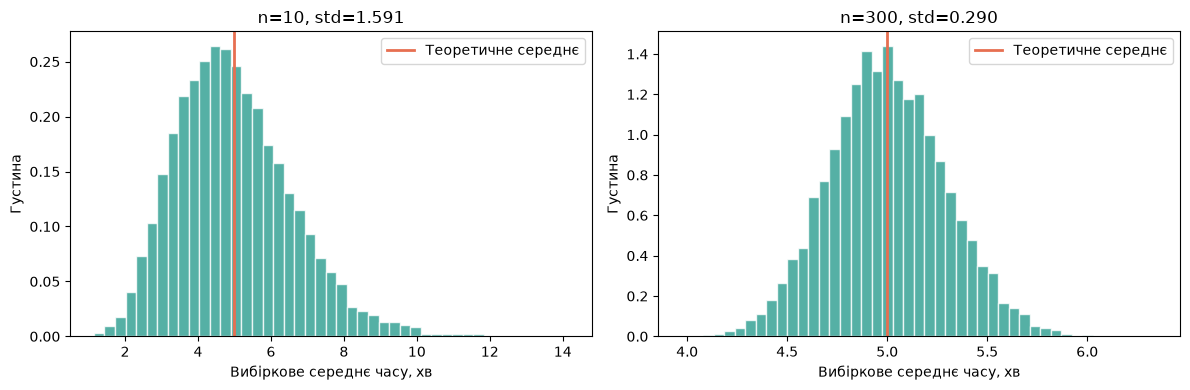

In [3]:
means_n10 = rng.exponential(scale=1 / lam, size=(n_repeats, 10)).mean(axis=1)
means_n300 = rng.exponential(scale=1 / lam, size=(n_repeats, 300)).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, sample_means, n in zip(axes, [means_n10, means_n300], [10, 300]):
    ax.hist(sample_means, bins=45, density=True, color='#2a9d8f', alpha=0.8, edgecolor='white')
    ax.axvline(true_mean, color='#e76f51', linewidth=2, label='Теоретичне середнє')
    ax.set_title(f'n={n}, std={sample_means.std():.3f}')
    ax.set_xlabel('Вибіркове середнє часу, хв')
    ax.set_ylabel('Густина')
    ax.legend()
plt.tight_layout()
plt.show()

**Висновок.** За `n=10` розподіл вибіркових середніх ще помітно скошений вправо, як вихідний експоненційний розподіл. За `n=300` гістограма стає значно симетричнішою та дзвоноподібною і концентрується біля 5 хв. Це ілюструє центральну граничну теорему.

## Завдання 3. Стандартна похибка: теорія проти симуляції

Для експоненційного розподілу `sigma = 1/lambda`, тому теоретична стандартна похибка дорівнює `SE = (1/lambda) / sqrt(n)`.

In [4]:
se_rows = []
for n in [10, 30, 100, 300]:
    sample_means = rng.exponential(scale=1 / lam, size=(n_repeats, n)).mean(axis=1)
    se_rows.append({
        'n': n,
        'теоретична SE': true_mean / np.sqrt(n),
        'виміряна std': sample_means.std(),
        'абсолютна різниця': abs(true_mean / np.sqrt(n) - sample_means.std())
    })

se_table = pd.DataFrame(se_rows)
display(se_table.style.format({'теоретична SE': '{:.4f}', 'виміряна std': '{:.4f}', 'абсолютна різниця': '{:.4f}'}))

,n,теоретична SE,виміряна std,абсолютна різниця
0,10,1.5811,1.5969,0.0158
1,30,0.9129,0.9041,0.0087
2,100,0.5000,0.4999,0.0001
3,300,0.2887,0.2874,0.0012


**Висновок.** Виміряне стандартне відхилення масиву вибіркових середніх близьке до теоретичної SE для всіх чотирьох значень `n`. Невеликі відмінності виникають через скінченну кількість повторів симуляції. Із ростом `n` стандартна похибка зменшується.

## Завдання 4. Закон убуваючої віддачі

Порівняємо стандартні похибки для `n=25` і `n=100`, де другий розмір у 4 рази більший.

In [5]:
se_25 = true_mean / np.sqrt(25)
se_100 = true_mean / np.sqrt(100)
print(f'SE для n=25: {se_25:.4f}')
print(f'SE для n=100: {se_100:.4f}')
print(f'Відношення SE(25) / SE(100): {se_25 / se_100:.1f}')

SE для n=25: 1.0000
SE для n=100: 0.5000
Відношення SE(25) / SE(100): 2.0


**Висновок.** При збільшенні `n` у 4 рази стандартна похибка зменшилася у 2 рази: з 1.0 до 0.5 хв. Це випливає з формули `SE = sigma / sqrt(n)`: квадратний корінь із 4 дорівнює 2, а не 4. Тому для зменшення похибки вдвічі потрібно зібрати в 4 рази більше спостережень.

## Завдання 5. Вплив кількості повторів (додатково)

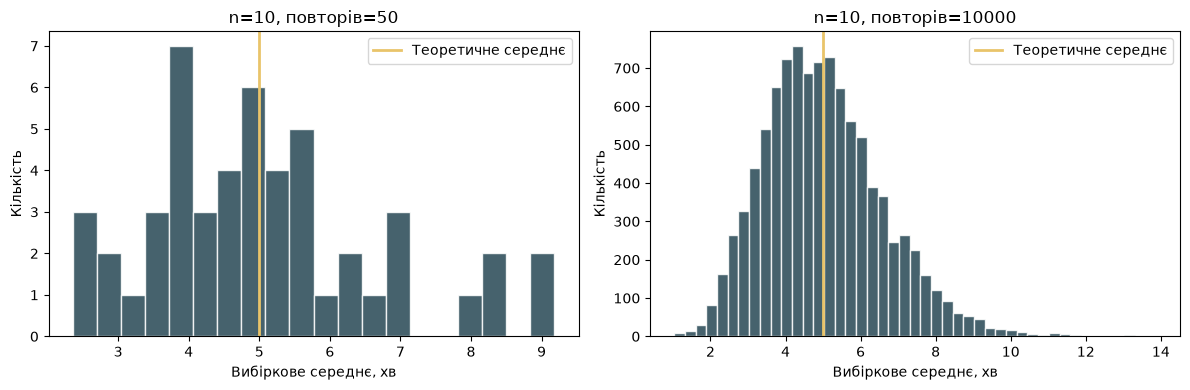

In [6]:
means_50 = rng.exponential(scale=1 / lam, size=(50, 10)).mean(axis=1)
means_10000 = rng.exponential(scale=1 / lam, size=(n_repeats, 10)).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, sample_means, repeats in zip(axes, [means_50, means_10000], [50, 10_000]):
    ax.hist(sample_means, bins=20 if repeats == 50 else 45, color='#264653', alpha=0.85, edgecolor='white')
    ax.axvline(true_mean, color='#e9c46a', linewidth=2, label='Теоретичне середнє')
    ax.set_title(f'n=10, повторів={repeats}')
    ax.set_xlabel('Вибіркове середнє, хв')
    ax.set_ylabel('Кількість')
    ax.legend()
plt.tight_layout()
plt.show()

**Висновок.** За 50 повторів гістограма має нерівний, випадковий вигляд, бо в ній мало спостережень. За 10 000 повторів форма розподілу помітно гладша. Параметр `n` впливає на форму самого розподілу середнього, а `n_repeats` визначає, наскільки добре гістограма відображає цей розподіл.

## Контрольні питання

**1. Чим відрізняються закон великих чисел і ЦГТ?**

Закон великих чисел відповідає на питання «куди прямує `x̄`?»: зі зростанням `n` вибіркове середнє прямує до теоретичного середнього. Центральна гранична теорема відповідає на питання «яка форма й розкид у `x̄`?»: за великих `n` розподіл вибіркового середнього наближається до нормального, а його стандартне відхилення близьке до `sigma / sqrt(n)`.

**2. Навіщо використано сильно скошений експоненційний розподіл?**

Так краще видно роботу ЦГТ: вихідні часи очікування мають праву асиметрію, але розподіл їхніх середніх стає симетричним і дзвоноподібним. Якби вихідні дані одразу були нормальними, цей перехід був би менш наочним.

**3. Чому стандартна похибка зменшується як `sqrt(n)`, а не як `n`?**

Формула стандартної похибки середнього має вигляд `SE = sigma / sqrt(n)`. Тому збільшення кількості спостережень у 4 рази зменшує похибку в 2 рази. Щоб зменшити похибку вдвічі, практично потрібно зібрати вчетверо більше даних, а не лише вдвічі більше.

## Підсумок

Для варіанта 1 (Київ, `lambda=0.20`) симуляція показала, що вибіркове середнє наближається до 5 хв зі зростанням розміру вибірки. Повторні вибірки продемонстрували перехід від скошеного розподілу середнього при `n=10` до майже нормального при `n=300`. Теоретичні стандартні похибки узгоджуються з виміряними симуляцією, а закон убуваючої віддачі пояснює, чому значне збільшення даних дає лише кореневе зменшення похибки.